# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.api as tsa

In [2]:
PLOT_SIZE = (10, 6)
PLOT_SIZE_X = PLOT_SIZE[0]
PLOT_SIZE_Y = PLOT_SIZE[1]

In [42]:
def general_plot(data, file, xlabel=None, ylabel=None, title=None, save_file=False):
    fig, ax = plt.subplots(figsize=PLOT_SIZE)
    sns.set_style("whitegrid")
    ax.plot(data.dropna(), color="black")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )   
    plt.show()

def decomp_plot(data, file, save_file=False):
    decomp_result = tsa.seasonal_decompose(data.dropna())
    fig = decomp_result.plot()
    fig.set_size_inches(PLOT_SIZE_X, PLOT_SIZE_Y)
    axes = fig.get_axes()

    for ax in axes:
        for line in ax.get_lines():
            line.set_color("black")
    
    axes[3].get_lines()[1].set_color("black")

    axes[0].set_title(None)
    axes[0].set_ylabel("Szereg czasowy")
    axes[1].set_ylabel("Trend")
    axes[2].set_ylabel("Sezonowość")
    axes[3].set_ylabel("Reszty")
    if save_file:
        fig.savefig(
            file,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )
    plt.show()

In [ ]:
monthly_data = pd.read_excel("../data/dane.xlsx", sheet_name="miesięczne", parse_dates=["data"], index_col="data")
quarterly_data = pd.read_excel("../data/dane.xlsx", sheet_name="kwartalne", parse_dates=["data"], index_col="data")
yearly_data = pd.read_excel("../data/dane.xlsx", sheet_name="roczne", parse_dates=["data"], index_col="data")

for col in monthly_data.columns:
    monthly_data[col] = monthly_data[col].asfreq("MS")

for col in quarterly_data.columns:
    quarterly_data[col] = quarterly_data[col].asfreq("QS")

for col in yearly_data.columns:
    yearly_data[col] = yearly_data[col].asfreq("YS")

monthly_data["tk_tow_lad_dyn"] = monthly_data["tk_tow_prac_przew"] / monthly_data["tk_tow_prac_eksp"]
monthly_data["tk_tow_masa_jedn"] = monthly_data["tk_tow_masa"] / monthly_data["tk_tow_prac_eksp"]
quarterly_data["tk_int_tran"] = monthly_data["tk_tow_prac_przew"].resample("QS").sum().div(quarterly_data["pkb"]).dropna()

# Transport kolejowy towarowy

## Zmienna masa towarów w transporcie kolejowym

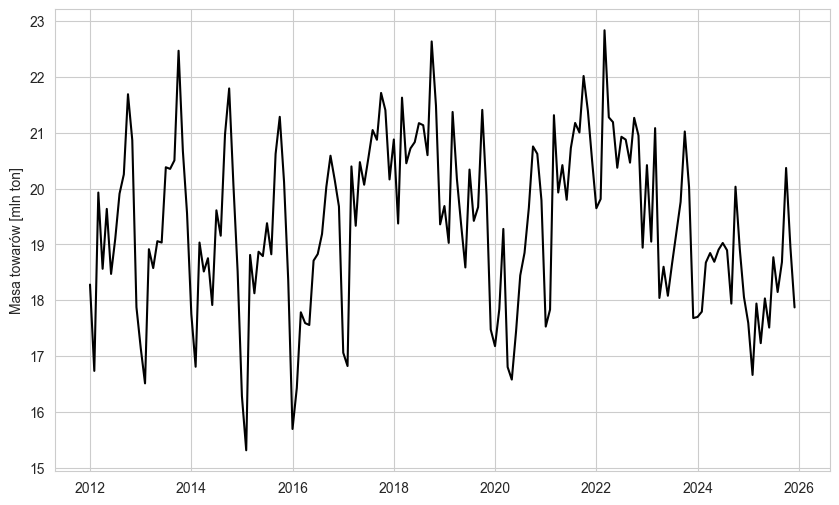

In [ ]:
general_plot(
    monthly_data["tk_tow_masa"],
    file="../figures/tk_tow_masa.png",
    ylabel="Masa towarów [mln ton]",
    title=None,
    save_file=False
)

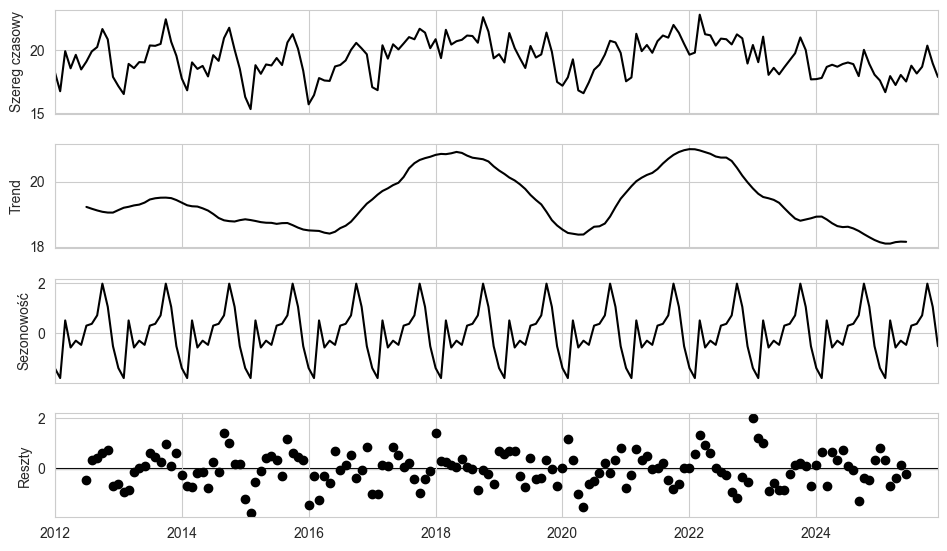

In [ ]:
decomp_plot(
    monthly_data["tk_tow_masa"],
    file="../figures/tk_tow_masa_decomp.png",
    save_file=False
)


## Zmienna praca przewozowa w transporcie kolejowym towarowym

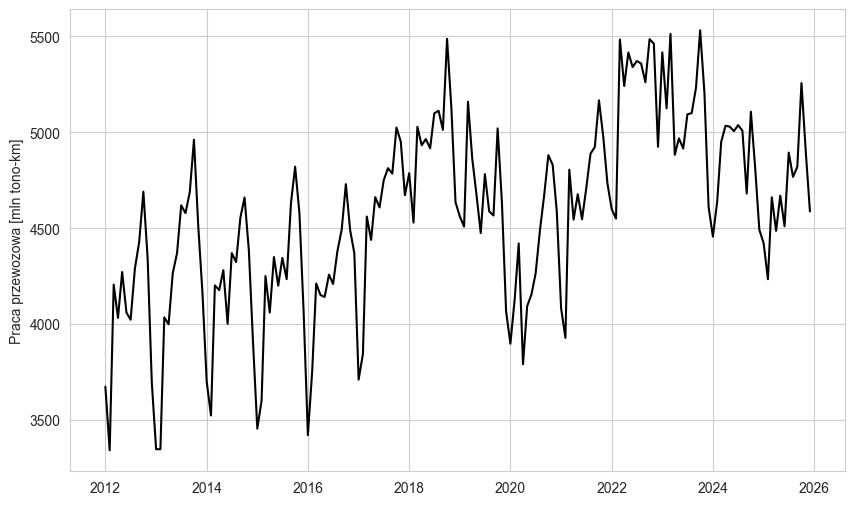

In [ ]:
general_plot(
    monthly_data["tk_tow_prac_przew"],
    file="../figures/tk_tow_prac_przew.png",
    ylabel="Praca przewozowa [mln tono-km]",
    title=None,
    save_file=False
)

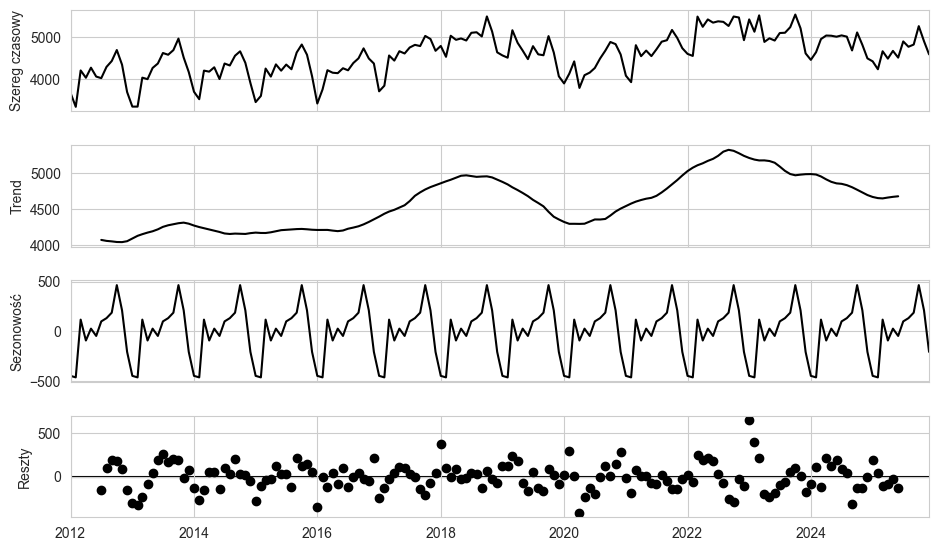

In [ ]:
decomp_plot(
    monthly_data["tk_tow_prac_przew"],
    file="../figures/tk_tow_prac_przew_decomp.png",
    save_file=False
)

## Zmienna praca eksploatacyjna w transporcie kolejowym towarowym

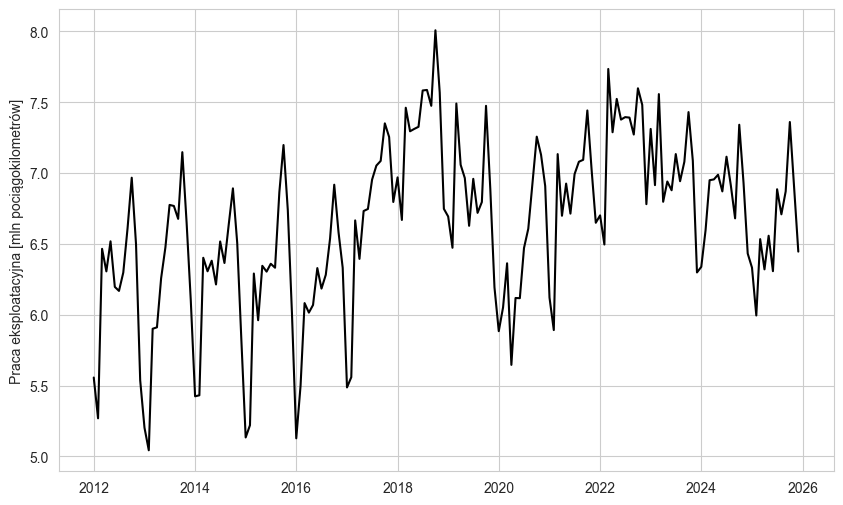

In [ ]:
general_plot(
    monthly_data["tk_tow_prac_eksp"],
    file="../figures/tk_tow_prac_eksp.png",
    ylabel="Praca eksploatacyjna [mln pociągokilometrów]",
    title=None,
    save_file=False
)

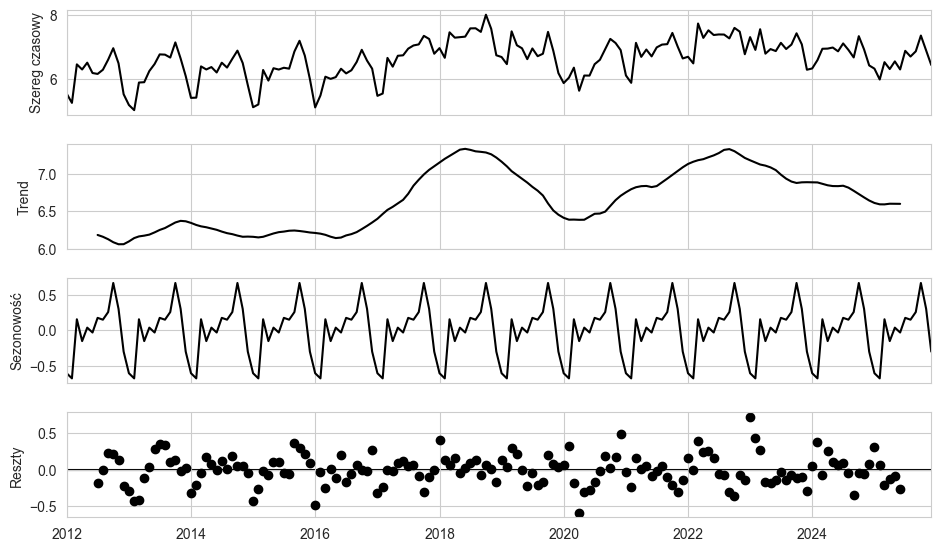

In [ ]:
decomp_plot(
    monthly_data["tk_tow_prac_eksp"],
    file="../figures/tk_tow_prac_eksp_decomp.png",
    save_file=False
)

## Zmienna ładowność dynamiczna w transporcie kolejowym towarowym

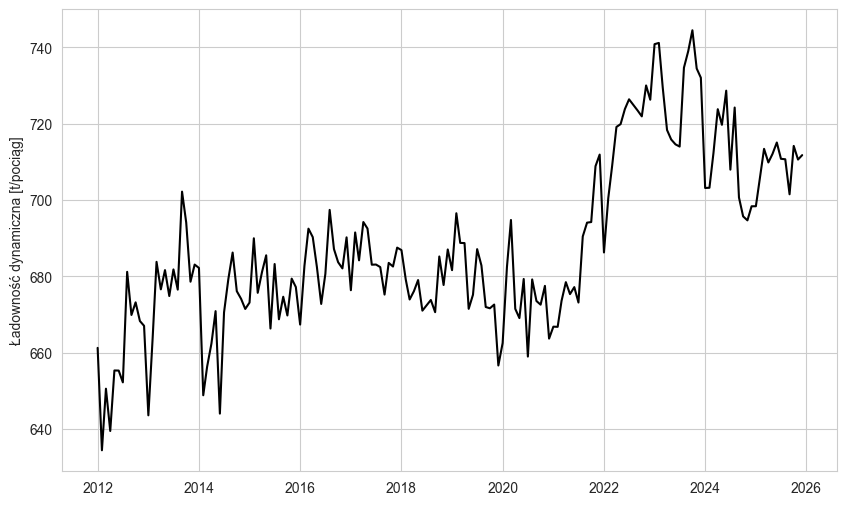

In [ ]:
general_plot(
    monthly_data["tk_tow_lad_dyn"],
    file="../figures/tk_tow_lad_dyn.png",
    ylabel="Ładowność dynamiczna [t/pociąg]",
    title=None,
    save_file=False
)

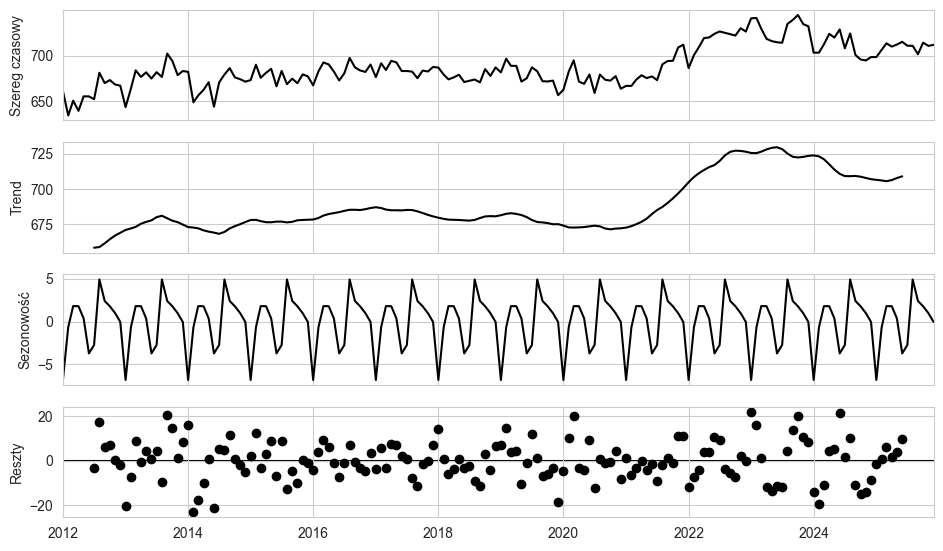

In [ ]:
decomp_plot(
    monthly_data["tk_tow_lad_dyn"],
    file="../figures/tk_tow_lad_dyn_decomp.png",
    save_file=False
)

## Zmienna masa jednostkowa w transporcie kolejowym

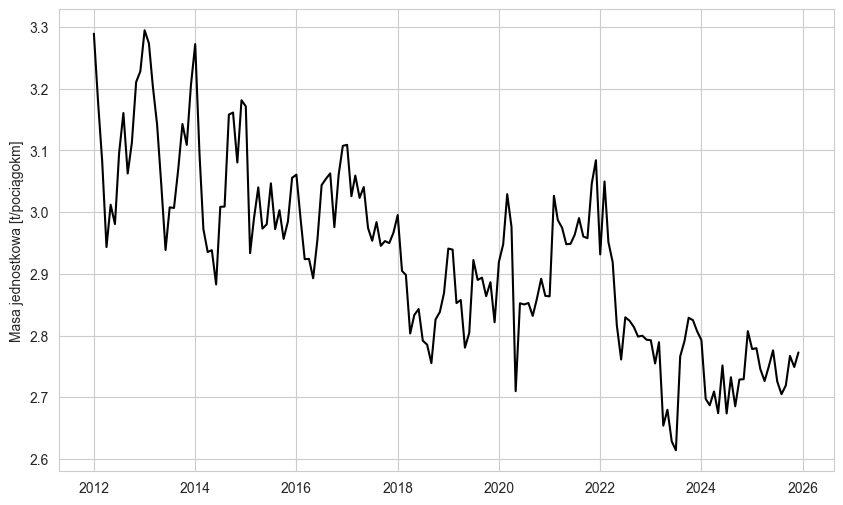

In [ ]:
general_plot(
    monthly_data["tk_tow_masa_jedn"],
    file="../figures/tk_tow_masa_jedn.png",
    ylabel="Masa jednostkowa [t/pociągokm]",
    title=None,
    save_file=False
)

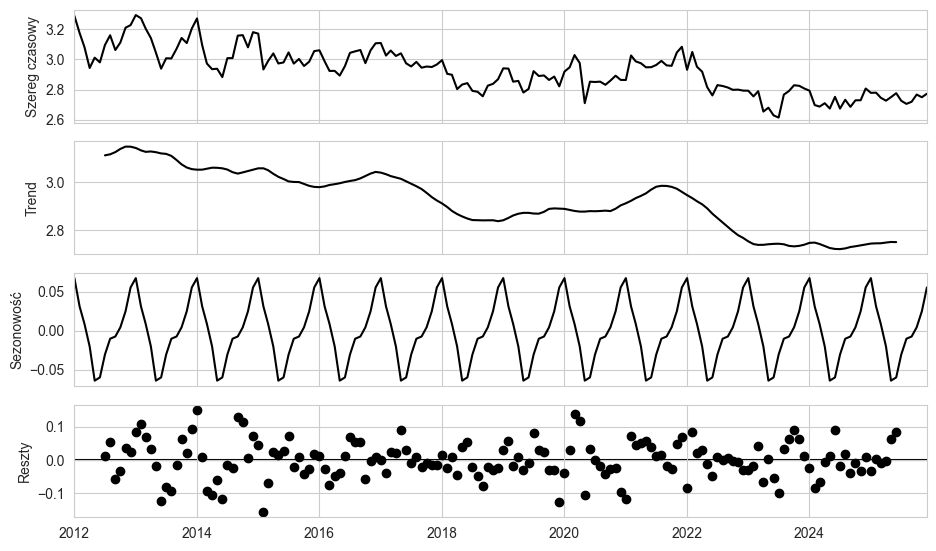

In [ ]:
decomp_plot(
    monthly_data["tk_tow_masa_jedn"],
    file="../figures/tk_tow_masa_jedn_decomp.png",
    save_file=False
)

## Zmienna intensywność transportowa

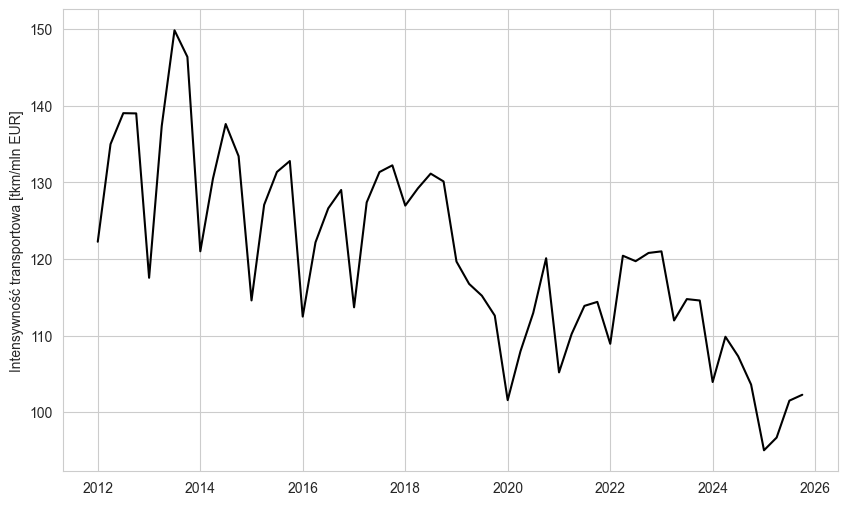

In [ ]:
general_plot(
    quarterly_data["tk_int_tran"],
    file="../figures/tk_int_tran.png",
    ylabel="Intensywność transportowa [tkm/mln EUR]",
    title=None,
    save_file=False
)

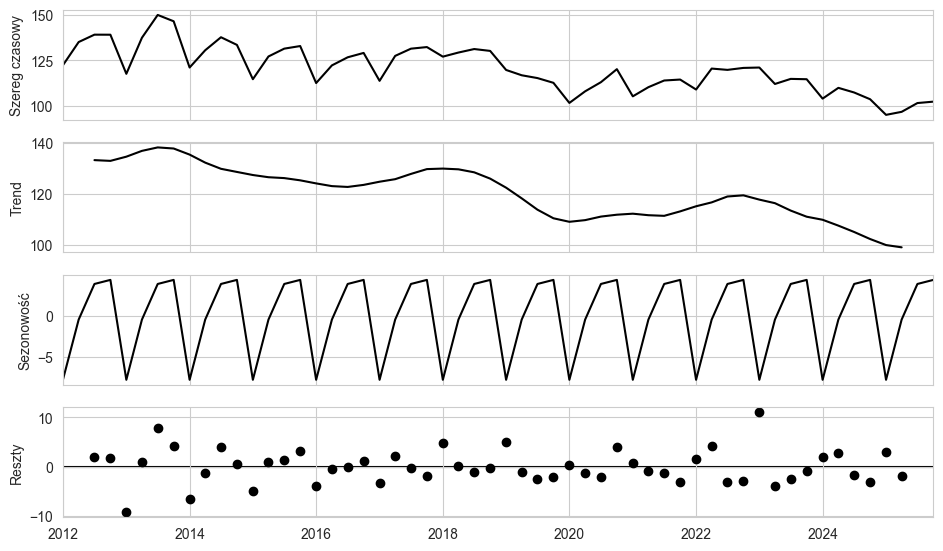

In [ ]:
decomp_plot(
    quarterly_data["tk_int_tran"],
    file="../figures/tk_int_tran_decomp.png",
    save_file=False
)

# Transport kolejowy pasażerski

## Zmienna liczba pasażerów

In [ ]:
general_plot(
    monthly_data["tk_pas_liczba"],
    file="../figures/tk_pas_liczba.png",
    ylabel="Liczba pasażerów [mln osób]",
    title=None,
    save_file=True
)

In [ ]:
decomp_plot(
    monthly_data["tk_pas_liczba"],
    file="../figures/tk_pas_liczba_decomp.png",
    save_file=True
)